# 09 — BPE Capability Analysis (2026-02-23)

## Objectif

Analyser les séquences d'outils dans les traces d'exécution via BPE (Byte-Pair Encoding)
et comparer les patterns découverts avec les capabilities déclarées dans `workflow_pattern`.

**Rappel** : Les capabilities existent déjà. Le BPE ne sert PAS à les découvrir.
Il sert à **valider** lesquelles sont des vrais patterns récurrents dans les données
vs dead weight dans le vocabulaire GRU.

### Contexte GRU
- 93.3% first-tool accuracy (beam audit 2026-02-23)
- 573 caps dans le vocab = dead weight (0 gradient, targets = tools-only)
- `capability_id` rempli sur 86.6% des traces (1845/2131)
- Objectif final : le GRU prédit directement une capability existante

### Ref littérature
- "Subwords as Skills" (Yoon et al., NeurIPS 2024) — BPE sur action sequences
- Sequitur (Nevill-Manning & Witten, 1997) — grammar induction O(n)

In [1]:
import psycopg2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import json
import re

conn = psycopg2.connect(
    host="localhost", port=5432, dbname="casys",
    user="casys", password="Kx9mP2vL7nQ4wRzT"
)
cur = conn.cursor()

def normalize_tool_id(tool_id):
    """FQDN -> short format (e.g., pml.mcp.std.psql_query.db48 -> std:psql_query)"""
    parts = tool_id.split('.')
    if len(parts) >= 4 and parts[0] in ('pml', 'local'):
        return f"{parts[2]}:{parts[3]}"
    return tool_id

print("Connected.")

Connected.


## 1. Charger les traces et les capabilities

In [2]:
# --- Traces : séquences de tools ---
cur.execute("""
    SELECT et.id, et.capability_id, et.task_results,
           et.initial_context->>'intent' as intent
    FROM execution_trace et
    WHERE et.task_results IS NOT NULL
      AND jsonb_typeof(et.task_results) = 'array'
      AND jsonb_array_length(et.task_results) >= 1
""")
raw_traces = cur.fetchall()

traces = []  # list of { id, cap_id, tools: [str], intent: str }
for trace_id, cap_id, task_results, intent in raw_traces:
    tools = []
    tr = task_results if isinstance(task_results, list) else json.loads(task_results)
    for t in tr:
        tool = t.get('tool')
        if tool:
            tools.append(normalize_tool_id(tool))
    if tools:
        traces.append({
            'id': str(trace_id),
            'cap_id': str(cap_id) if cap_id else None,
            'tools': tools,
            'intent': intent or '',
        })

print(f"{len(traces)} traces chargées")
print(f"{sum(1 for t in traces if t['cap_id'])} avec capability_id ({sum(1 for t in traces if t['cap_id'])/len(traces)*100:.1f}%)")

# Distribution des longueurs
lengths = [len(t['tools']) for t in traces]
len_dist = Counter(lengths)
multi_traces = [t for t in traces if len(t['tools']) > 1]
print(f"{len(multi_traces)} traces multi-tools ({len(multi_traces)/len(traces)*100:.1f}%)")
print(f"Longueur moyenne: {np.mean(lengths):.1f}, max: {max(lengths)}")

2220 traces chargées
1784 avec capability_id (80.4%)
339 traces multi-tools (15.3%)
Longueur moyenne: 1.5, max: 360


In [3]:
# --- Capabilities : définitions avec tools_used ---
cur.execute("""
    SELECT pattern_id, description, dag_structure->'tools_used' as tools_used,
           hierarchy_level
    FROM workflow_pattern
    WHERE dag_structure->'tools_used' IS NOT NULL
      AND jsonb_array_length(dag_structure->'tools_used') >= 1
""")
raw_caps = cur.fetchall()

capabilities = {}  # cap_id -> { desc, tools_set, tools_list, level }
for cap_id, desc, tools_raw, level in raw_caps:
    tools = tools_raw if isinstance(tools_raw, list) else json.loads(tools_raw)
    norm_tools = [normalize_tool_id(t) for t in tools if t]
    if norm_tools:
        capabilities[str(cap_id)] = {
            'desc': desc or '',
            'tools_set': set(norm_tools),
            'tools_list': norm_tools,
            'level': level or 0,
        }

# Stats
multi_caps = {k: v for k, v in capabilities.items() if len(v['tools_set']) > 1}
print(f"{len(capabilities)} capabilities chargées")
print(f"{len(multi_caps)} multi-tools ({len(multi_caps)/len(capabilities)*100:.1f}%)")

# Distribution
cap_sizes = Counter(len(v['tools_set']) for v in capabilities.values())
print(f"\nDistribution tools/cap:")
for size, cnt in sorted(cap_sizes.items()):
    print(f"  {size} tools: {cnt} caps")

541 capabilities chargées
166 multi-tools (30.7%)

Distribution tools/cap:
  1 tools: 375 caps
  2 tools: 76 caps
  3 tools: 48 caps
  4 tools: 22 caps
  5 tools: 7 caps
  6 tools: 11 caps
  7 tools: 2 caps


## 2. BPE sur les séquences de tools

Algorithme : fusionner itérativement la paire adjacente la plus fréquente.

In [4]:
def bpe_learn(sequences, num_merges=200, min_freq=3):
    """
    BPE sur des séquences de tokens.
    Retourne la liste des merges et le vocabulaire final.
    """
    # Copier les séquences (on va les modifier)
    corpus = [list(seq) for seq in sequences]
    merges = []  # (token_a, token_b, merged_token, freq)
    
    for step in range(num_merges):
        # Compter les paires adjacentes
        pair_freq = Counter()
        for seq in corpus:
            for i in range(len(seq) - 1):
                pair_freq[(seq[i], seq[i+1])] += 1
        
        if not pair_freq:
            break
        
        # Paire la plus fréquente
        best_pair, best_freq = pair_freq.most_common(1)[0]
        if best_freq < min_freq:
            break
        
        # Créer le token fusionné
        merged = f"({best_pair[0]}+{best_pair[1]})"
        merges.append((best_pair[0], best_pair[1], merged, best_freq))
        
        # Remplacer dans le corpus
        for seq_idx in range(len(corpus)):
            new_seq = []
            i = 0
            while i < len(corpus[seq_idx]):
                if (i < len(corpus[seq_idx]) - 1 and
                    corpus[seq_idx][i] == best_pair[0] and
                    corpus[seq_idx][i+1] == best_pair[1]):
                    new_seq.append(merged)
                    i += 2
                else:
                    new_seq.append(corpus[seq_idx][i])
                    i += 1
            corpus[seq_idx] = new_seq
        
        if (step + 1) % 50 == 0:
            print(f"  Merge {step+1}: {best_pair[0]} + {best_pair[1]} (freq={best_freq})")
    
    return merges, corpus


def expand_bpe_token(token):
    """Récursivement expand un token BPE en ses tools constituants."""
    if not token.startswith('('):
        return [token]
    # Remove outer parens, split on +
    inner = token[1:-1]
    # Find the + that splits the two parts (handle nested parens)
    depth = 0
    for i, ch in enumerate(inner):
        if ch == '(': depth += 1
        elif ch == ')': depth -= 1
        elif ch == '+' and depth == 0:
            left = inner[:i]
            right = inner[i+1:]
            return expand_bpe_token(left) + expand_bpe_token(right)
    return [token]  # fallback


print("BPE functions defined.")

BPE functions defined.


In [5]:
# Extraire les séquences multi-tools uniquement
sequences = [t['tools'] for t in traces if len(t['tools']) > 1]
print(f"BPE sur {len(sequences)} séquences multi-tools")
print(f"Tokens uniques avant BPE: {len(set(t for s in sequences for t in s))}")

merges, compressed = bpe_learn(sequences, num_merges=200, min_freq=3)

print(f"\n{len(merges)} merges effectués")
print(f"Tokens uniques après BPE: {len(set(t for s in compressed for t in s))}")

# Compression ratio
orig_len = sum(len(s) for s in sequences)
comp_len = sum(len(s) for s in compressed)
print(f"Compression: {orig_len} -> {comp_len} tokens ({comp_len/orig_len*100:.1f}%)")

BPE sur 339 séquences multi-tools
Tokens uniques avant BPE: 120
  Merge 50: ((syson:syson_element_insert_sysml+syson:syson_element_insert_sysml)+(syson:syson_element_insert_sysml+syson:syson_element_insert_sysml)) + ((syson:syson_element_insert_sysml+syson:syson_element_insert_sysml)+(syson:syson_element_insert_sysml+syson:syson_element_insert_sysml)) (freq=4)

75 merges effectués
Tokens uniques après BPE: 172
Compression: 1476 -> 608 tokens (41.2%)


In [6]:
# Top merges — les patterns les plus fréquents
print("=== Top 30 BPE Merges (sous-séquences les plus fréquentes) ===\n")
print(f"{'#':>3s}  {'Freq':>4s}  {'Pair':60s}  {'Expands to'}")
print("-" * 120)
for i, (a, b, merged, freq) in enumerate(merges[:30]):
    expanded = expand_bpe_token(merged)
    exp_str = ' -> '.join(expanded)
    pair_str = f"{a}  +  {b}"
    print(f"{i+1:>3d}  {freq:>4d}  {pair_str:60s}  [{len(expanded)} tools] {exp_str}")

=== Top 30 BPE Merges (sous-séquences les plus fréquentes) ===

  #  Freq  Pair                                                          Expands to
------------------------------------------------------------------------------------------------------------------------
  1   358  std:embedding_encode  +  std:embedding_encode                 [2 tools] std:embedding_encode -> std:embedding_encode
  2   178  (std:embedding_encode+std:embedding_encode)  +  (std:embedding_encode+std:embedding_encode)  [4 tools] std:embedding_encode -> std:embedding_encode -> std:embedding_encode -> std:embedding_encode
  3    88  ((std:embedding_encode+std:embedding_encode)+(std:embedding_encode+std:embedding_encode))  +  ((std:embedding_encode+std:embedding_encode)+(std:embedding_encode+std:embedding_encode))  [8 tools] std:embedding_encode -> std:embedding_encode -> std:embedding_encode -> std:embedding_encode -> std:embedding_encode -> std:embedding_encode -> std:embedding_encode -> std:embedding_encode
 

## 3. Alignement BPE ↔ Capabilities

Pour chaque merge BPE (sous-séquence fréquente), calculer le Jaccard similarity
avec chaque capability déclarée. Trois catégories :

- **Aligned** : pattern BPE ≈ capability existante (Jaccard > 0.5)
- **Orphan** : pattern BPE sans capability correspondante
- **Dead** : capability déclarée jamais vue dans les traces

In [7]:
def jaccard(set_a, set_b):
    if not set_a and not set_b:
        return 0.0
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union > 0 else 0.0


# Pour chaque merge BPE qui est un "skill" (>= 2 tools), chercher la meilleure cap
bpe_skills = []
for a, b, merged, freq in merges:
    expanded = expand_bpe_token(merged)
    if len(expanded) < 2:
        continue
    tool_set = set(expanded)
    
    # Best matching capability
    best_cap_id = None
    best_jaccard = 0.0
    best_cap_desc = ''
    for cap_id, cap in capabilities.items():
        j = jaccard(tool_set, cap['tools_set'])
        if j > best_jaccard:
            best_jaccard = j
            best_cap_id = cap_id
            best_cap_desc = cap['desc']
    
    bpe_skills.append({
        'merged': merged,
        'expanded': expanded,
        'tool_set': tool_set,
        'freq': freq,
        'best_cap_id': best_cap_id,
        'best_jaccard': best_jaccard,
        'best_cap_desc': best_cap_desc,
    })

# Catégoriser
aligned = [s for s in bpe_skills if s['best_jaccard'] >= 0.5]
partial = [s for s in bpe_skills if 0.0 < s['best_jaccard'] < 0.5]
orphan = [s for s in bpe_skills if s['best_jaccard'] == 0.0]

print(f"=== BPE Skills ({len(bpe_skills)} total) ===")
print(f"  Aligned (Jaccard >= 0.5):  {len(aligned)}")
print(f"  Partial (0 < J < 0.5):     {len(partial)}")
print(f"  Orphan (J = 0):            {len(orphan)}")

# Dead capabilities (not matched by any BPE skill)
matched_cap_ids = set(s['best_cap_id'] for s in bpe_skills if s['best_jaccard'] >= 0.5)
dead_caps = {k: v for k, v in multi_caps.items() if k not in matched_cap_ids}
alive_caps = {k: v for k, v in multi_caps.items() if k in matched_cap_ids}

print(f"\n=== Capabilities multi-tools ({len(multi_caps)}) ===")
print(f"  Alive (matched by BPE):    {len(alive_caps)}")
print(f"  Dead (no BPE match):       {len(dead_caps)}")

=== BPE Skills (75 total) ===
  Aligned (Jaccard >= 0.5):  68
  Partial (0 < J < 0.5):     0
  Orphan (J = 0):            7

=== Capabilities multi-tools (166) ===
  Alive (matched by BPE):    27
  Dead (no BPE match):       139


In [8]:
# Détail des skills alignés
print("=== Aligned BPE Skills -> Capabilities ===\n")
for s in sorted(aligned, key=lambda x: -x['freq'])[:20]:
    exp = ' -> '.join(s['expanded'])
    print(f"  freq={s['freq']:>3d}  J={s['best_jaccard']:.2f}  [{len(s['expanded'])} tools] {exp}")
    print(f"           -> cap: {s['best_cap_desc'][:70]}")
    print()

=== Aligned BPE Skills -> Capabilities ===

  freq= 81  J=1.00  [2 tools] std:psql_query -> std:psql_query
           -> cap: Test Issue 6 - create new capability with nested call

  freq= 51  J=1.00  [2 tools] syson:syson_element_children -> syson:syson_element_children
           -> cap: Display CoffeeMachine model tree with explorer viewer

  freq= 43  J=1.00  [2 tools] syson:syson_element_insert_sysml -> syson:syson_element_insert_sysml
           -> cap: Insert SysML interfaces (port connections) and constraint expressions 

  freq= 21  J=1.00  [2 tools] std:data_person -> std:data_person
           -> cap: Generate fake person with name, email, phone, job

  freq= 21  J=1.00  [3 tools] syson:syson_element_children -> syson:syson_element_children -> syson:syson_query_aql
           -> cap: Try different AQL paths to read LiteralString value from SysML model

  freq= 20  J=1.00  [2 tools] plm:plm_bom_flatten -> plm:plm_bom_cost
           -> cap: Flatten and cost a BOM using PLM to

In [9]:
# Détail des capabilities mortes
print(f"=== Dead Capabilities ({len(dead_caps)} multi-tools sans match BPE) ===\n")
for cap_id, cap in sorted(dead_caps.items(), key=lambda x: -len(x[1]['tools_set']))[:15]:
    tools_str = ', '.join(sorted(cap['tools_set']))
    print(f"  {cap_id[:8]}  [{len(cap['tools_set'])} tools]  {cap['desc'][:60]}")
    print(f"             {tools_str}")
    print()

=== Dead Capabilities (139 multi-tools sans match BPE) ===

  ad2147ff  [7 tools]  Test chain operations fusion - filter, map, reverse, join
             code:filter, code:join, code:map, code:modulo, code:multiply, code:reverse, code:strictEqual

  47ba8074  [7 tools]  Create a sample BOM, flatten it, then generate an inspection
             plm:plm_bom_flatten, plm:plm_control_plan, plm:plm_cycle_time, plm:plm_fair_generate, plm:plm_inspection_plan, plm:plm_routing_create, plm:plm_work_instruction

  07443423  [6 tools]  Check ERPNext data completeness for demo
             erpnext:erpnext_customer_list, erpnext:erpnext_item_list, erpnext:erpnext_sales_order_list, erpnext:erpnext_stock_balance, erpnext:erpnext_supplier_list, erpnext:erpnext_warehouse_list

  559d406a  [6 tools]  Final data summary for ERPNext demo
             erpnext:erpnext_customer_list, erpnext:erpnext_item_list, erpnext:erpnext_sales_order_list, erpnext:erpnext_stock_balance, erpnext:erpnext_supplier_list, erpne

## 4. Capabilities dans les traces — vue par `capability_id`

On sait que 86.6% des traces ont un `capability_id`.
Analysons la correspondance entre ce que le GRU voit (tools) et ce qu'il devrait prédire (cap).

In [10]:
# Pour chaque trace avec capability_id, comparer tools exécutés vs tools déclarés dans la cap
match_stats = {'exact': 0, 'subset': 0, 'superset': 0, 'overlap': 0, 'disjoint': 0, 'no_cap': 0}

for t in traces:
    if not t['cap_id'] or t['cap_id'] not in capabilities:
        match_stats['no_cap'] += 1
        continue
    
    trace_tools = set(t['tools'])
    cap_tools = capabilities[t['cap_id']]['tools_set']
    
    if trace_tools == cap_tools:
        match_stats['exact'] += 1
    elif trace_tools < cap_tools:
        match_stats['subset'] += 1
    elif trace_tools > cap_tools:
        match_stats['superset'] += 1
    elif trace_tools & cap_tools:
        match_stats['overlap'] += 1
    else:
        match_stats['disjoint'] += 1

total_with_cap = sum(v for k, v in match_stats.items() if k != 'no_cap')
print(f"=== Trace tools vs Capability tools_used ===")
print(f"  Total avec cap connue:  {total_with_cap}")
print(f"  Exact match:            {match_stats['exact']:>5d} ({match_stats['exact']/max(total_with_cap,1)*100:.1f}%)")
print(f"  Trace ⊂ cap (subset):   {match_stats['subset']:>5d} ({match_stats['subset']/max(total_with_cap,1)*100:.1f}%)")
print(f"  Trace ⊃ cap (superset): {match_stats['superset']:>5d} ({match_stats['superset']/max(total_with_cap,1)*100:.1f}%)")
print(f"  Partial overlap:        {match_stats['overlap']:>5d} ({match_stats['overlap']/max(total_with_cap,1)*100:.1f}%)")
print(f"  Disjoint:               {match_stats['disjoint']:>5d} ({match_stats['disjoint']/max(total_with_cap,1)*100:.1f}%)")
print(f"  No matching cap in DB:  {match_stats['no_cap']:>5d}")

=== Trace tools vs Capability tools_used ===
  Total avec cap connue:  1784
  Exact match:             1735 (97.3%)
  Trace ⊂ cap (subset):      28 (1.6%)
  Trace ⊃ cap (superset):     1 (0.1%)
  Partial overlap:            0 (0.0%)
  Disjoint:                  20 (1.1%)
  No matching cap in DB:    436


In [11]:
# Quelles capabilities sont réutilisées (>1 trace) ?
cap_usage = Counter(t['cap_id'] for t in traces if t['cap_id'])

reuse_dist = Counter()
for cap_id, cnt in cap_usage.items():
    if cnt == 1:
        reuse_dist['1x (unique)'] += 1
    elif cnt <= 3:
        reuse_dist['2-3x'] += 1
    elif cnt <= 10:
        reuse_dist['4-10x'] += 1
    elif cnt <= 50:
        reuse_dist['11-50x'] += 1
    else:
        reuse_dist['50x+'] += 1

print(f"=== Capability Reuse ===")
print(f"  {len(cap_usage)} distinct capabilities used")
for bucket in ['1x (unique)', '2-3x', '4-10x', '11-50x', '50x+']:
    cnt = reuse_dist.get(bucket, 0)
    pct = cnt / len(cap_usage) * 100 if cap_usage else 0
    bar = '█' * (cnt // 5)
    print(f"  {bucket:>12s}: {cnt:>4d} ({pct:>5.1f}%)  {bar}")

print(f"\nTop 10 most reused:")
for cap_id, cnt in cap_usage.most_common(10):
    cap = capabilities.get(cap_id, {})
    desc = cap.get('desc', '(unknown)')[:60]
    n_tools = len(cap.get('tools_set', []))
    print(f"  {cnt:>4d}x  [{n_tools} tools]  {desc}")

=== Capability Reuse ===
  540 distinct capabilities used
   1x (unique):  356 ( 65.9%)  ███████████████████████████████████████████████████████████████████████
          2-3x:  110 ( 20.4%)  ██████████████████████
         4-10x:   50 (  9.3%)  ██████████
        11-50x:   23 (  4.3%)  ████
          50x+:    1 (  0.2%)  

Top 10 most reused:
   439x  [1 tools]  Execute SQL queries on PostgreSQL database
    44x  [1 tools]  db:tableSchemas
    41x  [1 tools]  Generate fake person with name, email, phone, job
    30x  [1 tools]  Query latest execution trace
    29x  [1 tools]  Rename capabilities with new namespace, action, description 
    24x  [1 tools]  Display stock level chart from ERPNext
    23x  [1 tools]  Read and return file content
    22x  [1 tools]  Query execution traces from production database
    21x  [1 tools]  systemctl
    20x  [1 tools]  Etat des serveurs MCP


## 5. Visualisation

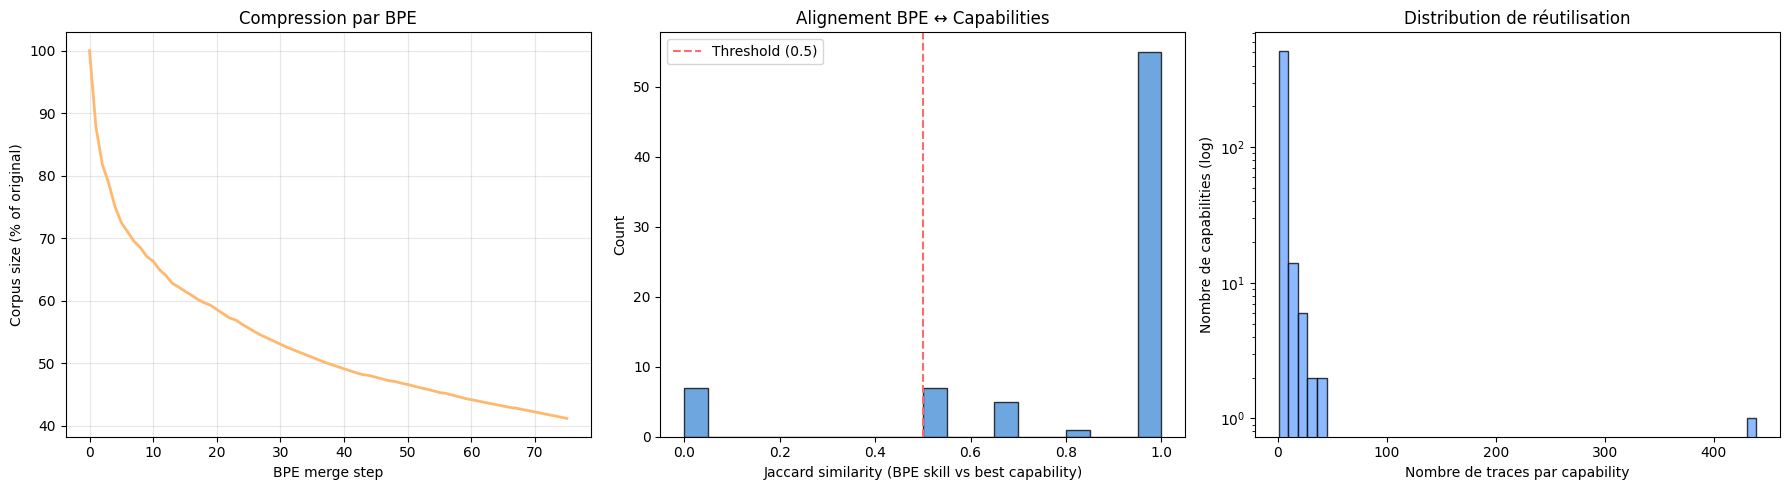

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Compression par merge step ---
# Recalculer la compression à chaque étape
step_corpus = [list(seq) for seq in sequences]
step_lengths = [sum(len(s) for s in step_corpus)]

for a, b, merged, freq in merges:
    for seq_idx in range(len(step_corpus)):
        new_seq = []
        i = 0
        while i < len(step_corpus[seq_idx]):
            if (i < len(step_corpus[seq_idx]) - 1 and
                step_corpus[seq_idx][i] == a and
                step_corpus[seq_idx][i+1] == b):
                new_seq.append(merged)
                i += 2
            else:
                new_seq.append(step_corpus[seq_idx][i])
                i += 1
        step_corpus[seq_idx] = new_seq
    step_lengths.append(sum(len(s) for s in step_corpus))

axes[0].plot(range(len(step_lengths)), [l/step_lengths[0]*100 for l in step_lengths],
             color='#FFB86F', linewidth=2)
axes[0].set_xlabel('BPE merge step')
axes[0].set_ylabel('Corpus size (% of original)')
axes[0].set_title('Compression par BPE')
axes[0].grid(True, alpha=0.3)

# --- 2. BPE Skill alignment distribution ---
jaccards = [s['best_jaccard'] for s in bpe_skills]
axes[1].hist(jaccards, bins=20, color='#4A90D9', edgecolor='#08080a', alpha=0.8)
axes[1].axvline(x=0.5, color='#FF6B6B', linestyle='--', label='Threshold (0.5)')
axes[1].set_xlabel('Jaccard similarity (BPE skill vs best capability)')
axes[1].set_ylabel('Count')
axes[1].set_title('Alignement BPE ↔ Capabilities')
axes[1].legend()

# --- 3. Capability reuse distribution ---
usage_counts = list(cap_usage.values())
axes[2].hist(usage_counts, bins=50, color='#6FA8FF', edgecolor='#08080a', alpha=0.8,
             log=True)
axes[2].set_xlabel('Nombre de traces par capability')
axes[2].set_ylabel('Nombre de capabilities (log)')
axes[2].set_title('Distribution de réutilisation')

plt.tight_layout()
plt.savefig('09-bpe-capability-analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Implications pour le GRU

Synthèse pour décider comment intégrer les capabilities dans le training.

In [13]:
# Combien de traces single-tool correspondent à une capability single-tool?
single_tool_traces = [t for t in traces if len(t['tools']) == 1 and t['cap_id']]
single_tool_caps = {k: v for k, v in capabilities.items() if len(v['tools_set']) == 1}

# Si le GRU prédit la capability au lieu du tool pour les single-tool caps:
# est-ce que c'est 1:1 (1 cap = 1 tool) ou N:1 (N caps = même tool) ?
tool_to_caps = defaultdict(list)
for cap_id, cap in single_tool_caps.items():
    tool = list(cap['tools_set'])[0]
    tool_to_caps[tool].append(cap_id)

multi_cap_tools = {t: caps for t, caps in tool_to_caps.items() if len(caps) > 1}

print(f"=== Single-tool analysis ===")
print(f"  Single-tool capabilities:   {len(single_tool_caps)}")
print(f"  Distinct tools covered:     {len(tool_to_caps)}")
print(f"  Tools with multiple caps:   {len(multi_cap_tools)} (N capabilities -> same tool)")
print(f"  Single-tool traces:         {len(single_tool_traces)}")

if multi_cap_tools:
    print(f"\n  Exemples tools -> N caps:")
    for tool, caps in sorted(multi_cap_tools.items(), key=lambda x: -len(x[1]))[:5]:
        descs = [capabilities[c]['desc'][:40] for c in caps[:3]]
        print(f"    {tool}: {len(caps)} caps -> {descs}")

print(f"\n=== Résumé pour le GRU ===")
print(f"  Traces avec capability_id:        {sum(1 for t in traces if t['cap_id'])} / {len(traces)}")
print(f"  Capabilities distinctes utilisées: {len(cap_usage)}")
print(f"  BPE skills alignés (J>=0.5):      {len(aligned)}")
print(f"  Capabilities mortes (multi-tool):  {len(dead_caps)}")
print(f"\n  -> Le ground truth capability_id est disponible pour 86.6% des traces.")
print(f"  -> La prédiction de capability est viable comme target GRU.")
print(f"  -> Les single-tool caps (N:1) nécessitent le capability_id pour désambiguïser.")

=== Single-tool analysis ===
  Single-tool capabilities:   375
  Distinct tools covered:     161
  Tools with multiple caps:   79 (N capabilities -> same tool)
  Single-tool traces:         1507

  Exemples tools -> N caps:
    std:psql_query: 26 caps -> ['Test Issue 6 - create new capability wit', 'Test simple FQDN normalization', 'Query execution_trace with JSON stringif']
    filesystem:read_file: 14 caps -> ['Test chain: read JSON file, parse, filte', 'Test layerIndex in execute_locally respo', 'Simple 2-layer test with file read']
    syson:syson_element_insert_sysml: 11 caps -> ['Insert SysML interfaces (port connection', 'Add Onshape document/element ID referenc', 'Insert SysML port usages on parts and co']
    filesystem:get_file_info: 10 caps -> ['Test skip with b independent between fil', 'Test parallel then converge pattern - no', 'Get file info for multiple config files']
    syson:syson_query_aql: 9 caps -> ['Query InterfaceUsage, ConnectionUsage, a', 'Read mass or numeric

In [14]:
cur.close()
conn.close()
print("Done.")

Done.
